In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
heart_df = pd.read_csv("../data/raw/heart.csv")
diabetes_df = pd.read_csv("../data/raw/diabetes.csv")
cancer_df = pd.read_csv("../data/raw/breast_cancer.csv")

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [3]:
datasets = {
    "Heart": heart_df,
    "Diabetes": diabetes_df,
    "Cancer": cancer_df
}

for name, df in datasets.items():
    print("\n====================")
    print(name)
    print("====================")
    print(df.info())
    print(df.isnull().sum())


Heart
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Diabe

In [4]:
# Handling missing values (if any)

heart_df.fillna(heart_df.median(numeric_only=True), inplace=True)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [5]:
# Diabetes dataset cleaning

cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in cols:
    diabetes_df[col] = diabetes_df[col].replace(0, np.nan)
    diabetes_df[col].fillna(diabetes_df[col].median(), inplace=True)

/var/folders/5b/5zqbkshd1s3fzhwrgxhly9gh0000gn/T/ipykernel_14003/750350509.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  diabetes_df[col].fillna(diabetes_df[col].median(), inplace=True)
/var/folders/5b/5zqbkshd1s3fzhwrgxhly9gh0000gn/T/ipykernel_14003/750350509.py:7: ChainedAssignmentError: A value is being set on a copy of a Da

In [6]:
#Cancer dataset cleaning

cancer_df.fillna(cancer_df.median(numeric_only=True), inplace=True)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


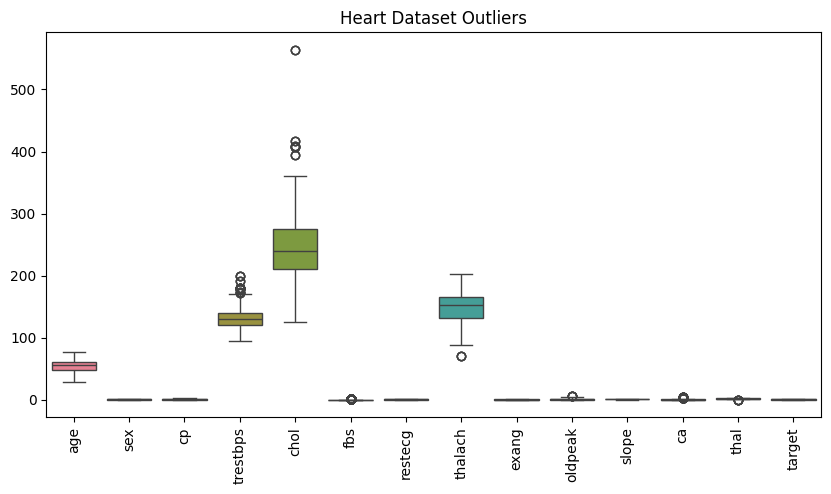

In [7]:
#Outlier Detection 

plt.figure(figsize=(10,5))
sns.boxplot(data=heart_df)
plt.xticks(rotation=90)
plt.title("Heart Dataset Outliers")
plt.show()

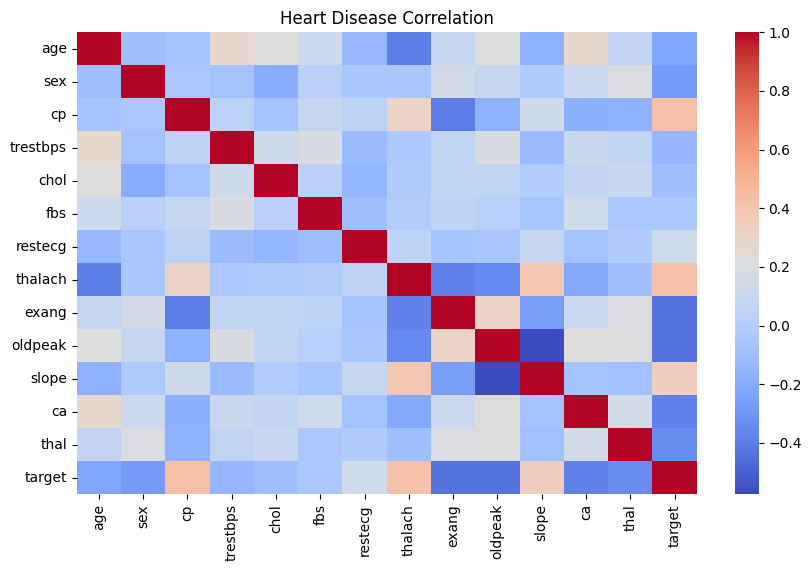

In [8]:
#Correlation Analysis

#Heart Disease

plt.figure(figsize=(10,6))
sns.heatmap(heart_df.corr(), cmap="coolwarm")
plt.title("Heart Disease Correlation")
plt.show()


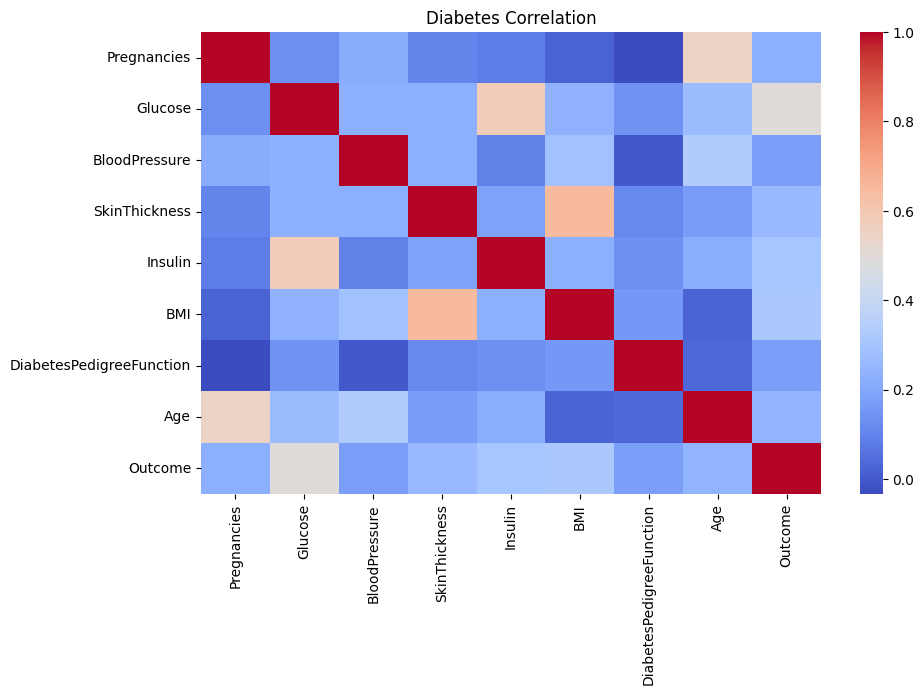

In [9]:
#Dianetes

plt.figure(figsize=(10,6))
sns.heatmap(diabetes_df.corr(), cmap="coolwarm")
plt.title("Diabetes Correlation")
plt.show()

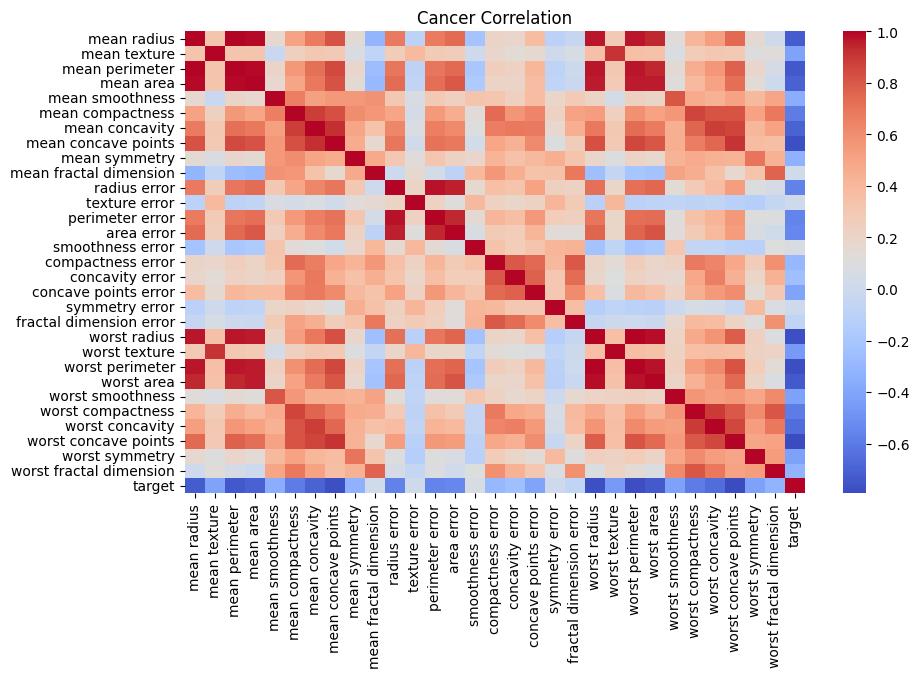

In [10]:
#Cancer
plt.figure(figsize=(10,6))
sns.heatmap(cancer_df.corr(), cmap="coolwarm")
plt.title("Cancer Correlation")
plt.show()

Feature and Target Split

In [11]:
#Heart Disease

X_heart = heart_df.drop("target", axis=1)
y_heart = heart_df["target"]

In [12]:
# Diabetes

X_diabetes = diabetes_df.drop("Outcome", axis=1)
y_diabetes = diabetes_df["Outcome"]

In [13]:
#Cancer

X_cancer = cancer_df.drop("target", axis=1)
y_cancer = cancer_df["target"]

Train Test Split

In [14]:
Xh_train, Xh_test, yh_train, yh_test = train_test_split(
    X_heart, y_heart, test_size=0.2, random_state=42
)

Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    X_diabetes, y_diabetes, test_size=0.2, random_state=42
)

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42
)

Feature Scaling

In [15]:
scaler_heart = StandardScaler()
scaler_diabetes = StandardScaler()
scaler_cancer = StandardScaler()

Applying Scaling

In [16]:
Xh_train = scaler_heart.fit_transform(Xh_train)
Xh_test = scaler_heart.transform(Xh_test)

Xd_train = scaler_diabetes.fit_transform(Xd_train)
Xd_test = scaler_diabetes.transform(Xd_test)

Xc_train = scaler_cancer.fit_transform(Xc_train)
Xc_test = scaler_cancer.transform(Xc_test)

Save Processed Data

In [17]:
import os

os.makedirs("../data/processed", exist_ok=True)

np.save("../data/processed/Xh_train.npy", Xh_train)
np.save("../data/processed/Xh_test.npy", Xh_test)
np.save("../data/processed/yh_train.npy", yh_train)
np.save("../data/processed/yh_test.npy", yh_test)

np.save("../data/processed/Xd_train.npy", Xd_train)
np.save("../data/processed/Xd_test.npy", Xd_test)
np.save("../data/processed/yd_train.npy", yd_train)
np.save("../data/processed/yd_test.npy", yd_test)

np.save("../data/processed/Xc_train.npy", Xc_train)
np.save("../data/processed/Xc_test.npy", Xc_test)
np.save("../data/processed/yc_train.npy", yc_train)
np.save("../data/processed/yc_test.npy", yc_test)

print("All processed datasets saved successfully!")

All processed datasets saved successfully!
